In [ ]:
### ============================================================
### Lecture 1: Baseline Forecasts, Moving Average, and ARMA
### Data source: Yahoo Finance (via yfinance) — S&P 500
### ============================================================

> **Where we left off (Lecture 1 Part A):**
> We built an AR(2) on demeaned log returns of the S&P 500.
> R² ≈ 0 — the model is barely better than predicting zero every day.
>
> **Today (Part B):** Before rushing to more complex models,
> we ask: *what is the simplest possible forecast?*
> We start with three **baseline forecasts**, add moving averages,
> and build intuition for when and why they fail — which sets up ARMA.

---
## Setup — Rebuild the S&P 500 Data

Same data as Part A: S&P 500 log returns, 2020–2024, demeaned.

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
import warnings; warnings.filterwarnings('ignore')

# ── colour palette (same as Part A) ─────────────────────────────────
C_ACT  = '#2166AC'    # actual series
C_FIT  = '#D6604D'    # fitted / forecast
C_UP   = '#1A9850'    # positive / bullish
C_DOWN = '#D73027'    # negative / bearish
C_GRAY = '#888888'    # secondary
C_MA20 = '#E6A817'    # MA(20)
C_MA60 = '#9B59B6'    # MA(60)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F8F8',
    'axes.edgecolor': '#DDDDDD', 'axes.grid': True,
    'grid.color': '#EEEEEE',     'grid.linewidth': 0.8,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

In [3]:
# ── download S&P 500 ─────────────────────────────────────────────────
try:
    sp500 = yf.download('^GSPC', start='2020-01-01', end='2024-12-31',
                        auto_adjust=True, progress=False)['Close'].squeeze().dropna()
    print(f'Downloaded {len(sp500)} trading days from Yahoo Finance')
except Exception:
    # ── synthetic fallback (same seed as Part A) ─────────────────────
    np.random.seed(42)
    dates = pd.date_range('2020-01-02', '2024-12-31', freq='B')
    n = len(dates)
    lr_raw = np.random.normal(0.0003, 0.012, n)
    vol = np.ones(n)
    for t in range(1, n):
        vol[t] = 0.1 + 0.85*vol[t-1] + 0.05*(lr_raw[t-1]**2/0.012**2)
    lr = lr_raw * np.sqrt(vol)
    sp500 = pd.Series(3200 * np.exp(np.cumsum(lr)), index=dates, name='Close')
    print(f'Using synthetic fallback: {len(sp500)} trading days')

# ── log return and demeaned return ───────────────────────────────────
log_ret  = np.log(sp500 / sp500.shift(1)).dropna()
ret_mean = log_ret.mean()
dm_ret   = log_ret - ret_mean          # demeaned log return  r̃_t

print(f'Log return mean : {ret_mean:.6f}  ({ret_mean*252*100:.2f}% annualised)')
print(f'Log return std  : {log_ret.std():.4f}  ({log_ret.std()*np.sqrt(252)*100:.1f}% annualised vol)')
print(f'Sample          : {log_ret.index[0].date()}  →  {log_ret.index[-1].date()}')

Downloaded 1257 trading days from Yahoo Finance
Log return mean : 0.000474  (11.94% annualised)
Log return std  : 0.0135  (21.4% annualised vol)
Sample          : 2020-01-03  →  2024-12-30


---
## Section 1 — Three Baseline Forecasts

Before any sophisticated model, we should know what a *naive* forecast looks like.
These three baselines require **no estimation** and serve as the floor we must beat.

---

### Baseline 1 — Zero Forecast  ("the market has no memory")

&emsp; **ŷ_{t+1} = 0**

On demeaned log returns, the best unconditional guess is zero.
This follows directly from the definition of demeaning: E[r̃_t] = 0.

- **When it works:** the series has no autocorrelation — knowing yesterday tells you nothing.
- **When it fails:** the series has momentum or mean-reversion (i.e., autocorrelation ≠ 0).
- **S&P 500 verdict:** AR(1) coefficient ≈ −0.02, R² ≈ 0.0004 → barely beats zero.

---

### Baseline 2 — Naïve Forecast  ("tomorrow = today")

&emsp; **ŷ_{t+1} = y_t**

Simply copy the last observation forward.
On *price levels* this works surprisingly well (random walk hypothesis).
On *returns* it performs poorly — yesterday's large return does not repeat.

- **When it works:** price levels, exchange rates, any near-random-walk series.
- **When it fails:** mean-reverting series, or any series where returns are not autocorrelated.
- **S&P 500 verdict on returns:** RMSE ≈ 0.017 — *worse* than the zero forecast (≈ 0.012).

---

### Baseline 3 — Seasonal Naïve  ("same day last cycle")

&emsp; **ŷ_{t+1} = y_{t − m}**

Copy the value from the same point in the previous season.
For weekly data with annual seasonality, m = 52.
For daily stock returns there is no reliable seasonal pattern, so this fails.

- **When it works:** retail sales, electricity demand, any series with strong, stable seasonality.
- **When it fails:** financial returns (no stable seasonality), or after a structural break.
- **S&P 500 verdict:** no seasonal pattern in daily log returns → no gain over zero forecast.

---

### Baseline 4 — AR(1)  ("one lag of history")

&emsp; **ŷ_{t+1} = β₁ · r̃_t** &emsp; (no intercept on demeaned series)

The simplest autoregressive model. Equivalent to OLS with a single predictor.
As we showed in Part A, on S&P 500 demeaned returns:

| | AR(1) estimate |
|---|---|
| β₁ | ≈ −0.02 (very small, negative) |
| R² | ≈ 0.0004 |

The coefficient is statistically near zero.
AR(1) is barely distinguishable from the zero forecast.

**The uncomfortable truth:** for daily S&P 500 returns,
all four baselines perform similarly — RMSE hovers around σ ≈ 0.012.
We need something smarter. Enter: **Moving Average**.

---
## Section 2 — Moving Average

A **moving average of order k** (MA(k) as a smoother, not the ARMA component) replaces
each value with the mean of the surrounding k observations:

&emsp; **MA_k(t) = (y_t + y_{t-1} + … + y_{t-k+1}) / k**

As a *forecast*, the trailing MA uses only past values:

&emsp; **ŷ_{t+1} = (y_t + y_{t-1} + … + y_{t-k+1}) / k**

Two uses to keep separate:

1. **Smoother** — applied to *price levels* to reveal the underlying trend.
   Traders use MA(20) and MA(60) as trend signals.
2. **Forecast** — applied to *returns* as a predictor of tomorrow's return.
   As k grows, the forecast converges to zero (the sample mean).

The plots below show both.

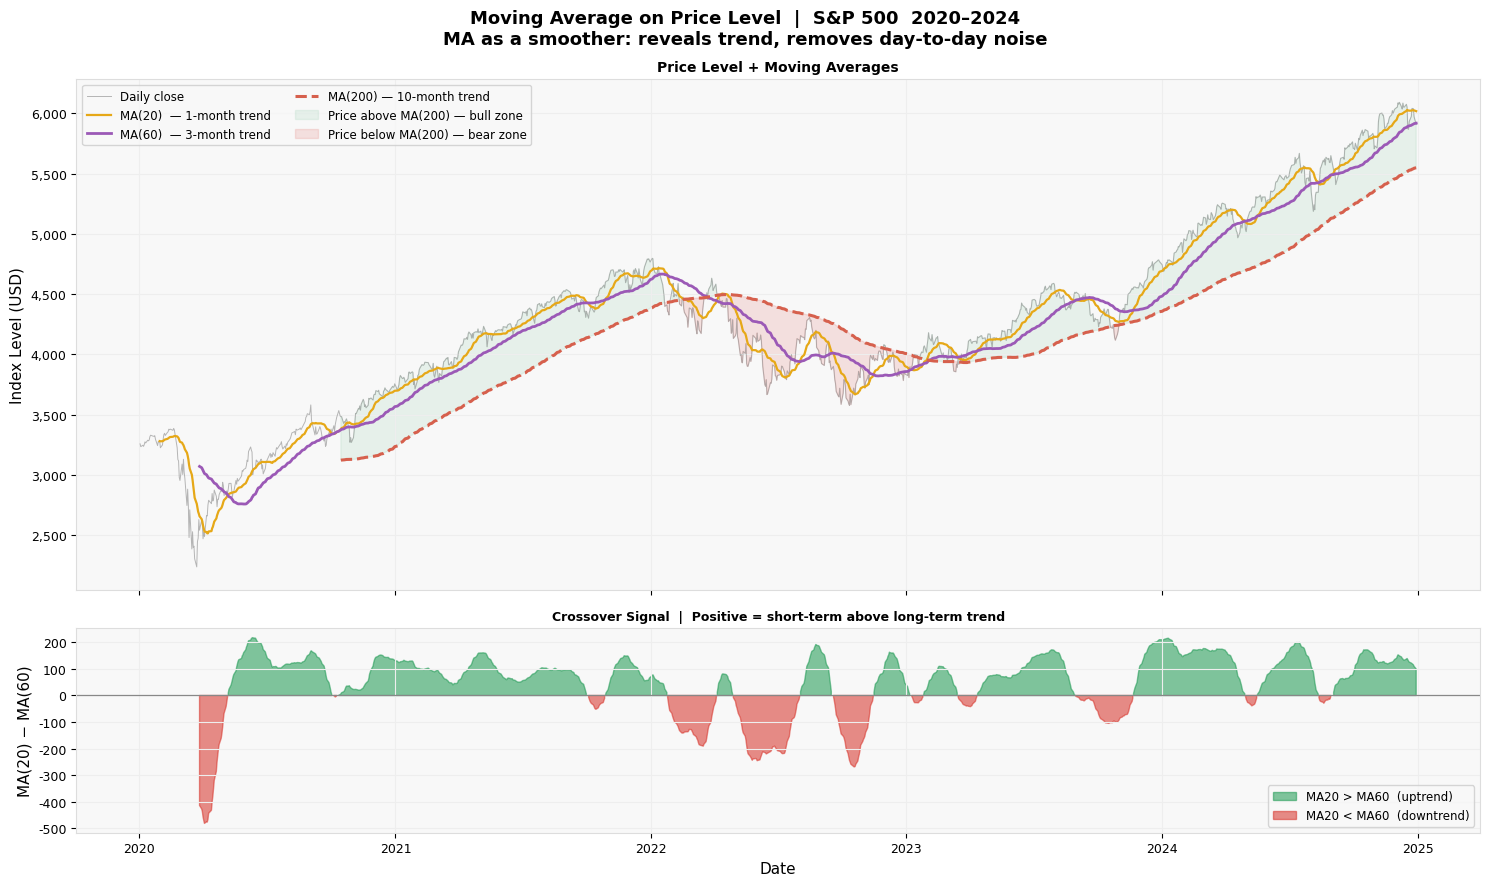

In [4]:
# ── Plot 1: MA on price levels — trend signal ────────────────────────
ma20  = sp500.rolling(20).mean()
ma60  = sp500.rolling(60).mean()
ma200 = sp500.rolling(200).mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1]})
fig.suptitle(
    'Moving Average on Price Level  |  S&P 500  2020–2024\n'
    'MA as a smoother: reveals trend, removes day-to-day noise',
    fontweight='bold', fontsize=13)

# ── top: price + MAs ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(sp500.index, sp500.values,
        color=C_GRAY, lw=0.7, alpha=0.6, label='Daily close')
ax.plot(ma20.index,  ma20.values,
        color=C_MA20, lw=1.6, label='MA(20)  — 1-month trend')
ax.plot(ma60.index,  ma60.values,
        color=C_MA60, lw=2.0, label='MA(60)  — 3-month trend')
ax.plot(ma200.index, ma200.values,
        color=C_FIT,  lw=2.2, ls='--', label='MA(200) — 10-month trend')

# shade above/below MA200 as bull/bear signal
common = sp500.index[~ma200.isna()]
ax.fill_between(common,
                sp500.reindex(common), ma200.reindex(common),
                where=sp500.reindex(common) >= ma200.reindex(common),
                alpha=0.08, color=C_UP,   label='Price above MA(200) — bull zone')
ax.fill_between(common,
                sp500.reindex(common), ma200.reindex(common),
                where=sp500.reindex(common) < ma200.reindex(common),
                alpha=0.12, color=C_DOWN, label='Price below MA(200) — bear zone')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.set_ylabel('Index Level (USD)')
ax.set_title('Price Level + Moving Averages', fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left', ncol=2)

# ── bottom: MA20 − MA60 spread (crossover signal) ────────────────────
ax2 = axes[1]
spread = (ma20 - ma60).dropna()
ax2.fill_between(spread.index, spread.values, 0,
                 where=spread.values >= 0, color=C_UP,   alpha=0.55,
                 label='MA20 > MA60  (uptrend)')
ax2.fill_between(spread.index, spread.values, 0,
                 where=spread.values < 0,  color=C_DOWN, alpha=0.55,
                 label='MA20 < MA60  (downtrend)')
ax2.axhline(0, color=C_GRAY, lw=0.9)
ax2.set_ylabel('MA(20) − MA(60)')
ax2.set_xlabel('Date')
ax2.set_title('Crossover Signal  |  Positive = short-term above long-term trend',
              fontsize=9, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.legend(fontsize=8.5)

plt.tight_layout()
plt.show()

Forecast RMSE on demeaned log returns  (full sample)
  Zero forecast         : RMSE = 0.01350  (1.000 × σ)
  Naïve (r_{t-1})       : RMSE = 0.02075  (1.536 × σ)
  MA(5)                 : RMSE = 0.01476  (1.093 × σ)
  MA(20)                : RMSE = 0.01393  (1.032 × σ)
  MA(60)                : RMSE = 0.01130  (0.837 × σ)

  σ_actual = 0.01350  (benchmark — just predicting zero)

Key insight: all forecasts hover near σ_actual.
MA averaging past returns converges to zero — barely better than guessing zero.


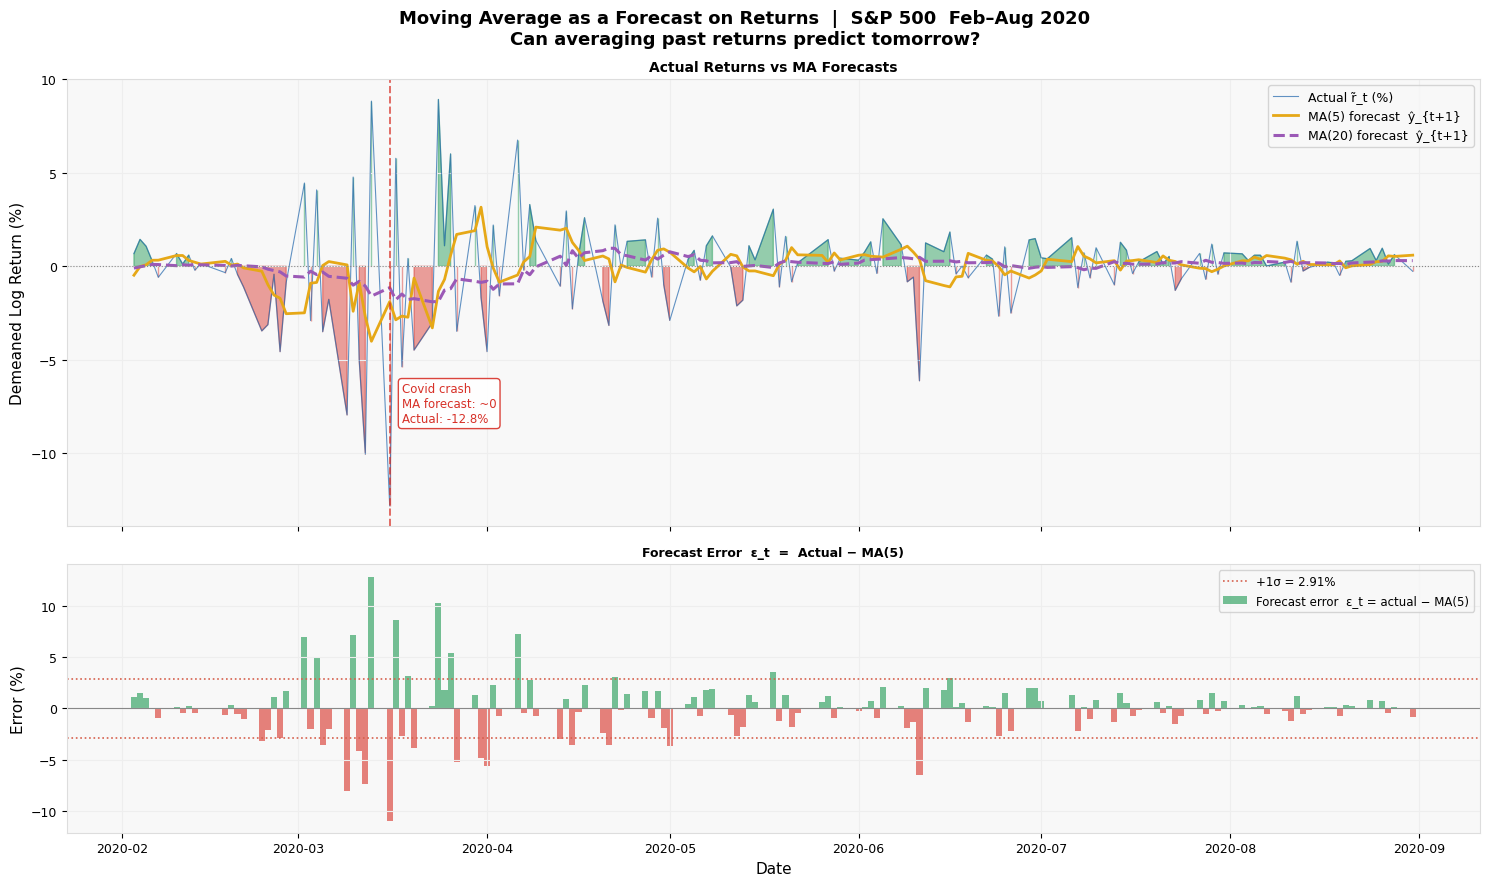

In [5]:
# ── Plot 2: MA as a forecast on demeaned log returns ─────────────────
# shift(1): forecast at time t uses data up to t-1 only (no look-ahead)
ma5_fcst  = dm_ret.rolling(5).mean().shift(1)
ma20_fcst = dm_ret.rolling(20).mean().shift(1)
ma60_fcst = dm_ret.rolling(60).mean().shift(1)

# ── RMSE table ────────────────────────────────────────────────────────
methods = {
    'Zero forecast':   pd.Series(0.0, index=dm_ret.index),
    'Naïve (r_{t-1})': dm_ret.shift(1),
    'MA(5)':           ma5_fcst,
    'MA(20)':          ma20_fcst,
    'MA(60)':          ma60_fcst,
}
print('Forecast RMSE on demeaned log returns  (full sample)')
print('=' * 48)
sigma_actual = dm_ret.std()
for name, fcst in methods.items():
    err = (dm_ret - fcst).dropna()
    rmse = err.std()
    ratio = rmse / sigma_actual
    print(f'  {name:22s}: RMSE = {rmse:.5f}  ({ratio:.3f} × σ)')
print()
print(f'  σ_actual = {sigma_actual:.5f}  (benchmark — just predicting zero)')
print()
print('Key insight: all forecasts hover near σ_actual.')
print('MA averaging past returns converges to zero — barely better than guessing zero.')

# ── show a 120-day window: actual vs MA forecasts ─────────────────────
window = slice('2020-02-01', '2020-08-31')   # includes Covid crash
act_w   = dm_ret[window] * 100
ma5_w   = ma5_fcst[window] * 100
ma20_w  = ma20_fcst[window] * 100

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1.2]})
fig.suptitle(
    'Moving Average as a Forecast on Returns  |  S&P 500  Feb–Aug 2020\n'
    'Can averaging past returns predict tomorrow?',
    fontweight='bold', fontsize=13)

# ── top panel: actual returns + MA forecasts ──────────────────────────
ax = axes[0]
ax.fill_between(act_w.index, act_w.values, 0,
                where=act_w.values >= 0, color=C_UP,   alpha=0.45)
ax.fill_between(act_w.index, act_w.values, 0,
                where=act_w.values <  0, color=C_DOWN, alpha=0.45)
ax.plot(act_w.index, act_w.values,
        color=C_ACT, lw=0.8, alpha=0.7, label='Actual r̃_t (%)')
ax.plot(ma5_w.index,  ma5_w.values,
        color=C_MA20, lw=2.0, label='MA(5) forecast  ŷ_{t+1}')
ax.plot(ma20_w.index, ma20_w.values,
        color=C_MA60, lw=2.2, ls='--', label='MA(20) forecast  ŷ_{t+1}')
ax.axhline(0, color=C_GRAY, lw=0.8, ls=':')

# annotate the crash
crash_date = dm_ret[window].abs().idxmax()
ax.axvline(crash_date, color=C_DOWN, lw=1.4, ls='--', alpha=0.7)
ax.text(crash_date + pd.Timedelta(days=2),
        act_w.min() * 0.65,
        f'Covid crash\nMA forecast: ~0\nActual: {act_w[crash_date]:.1f}%',
        fontsize=8.5, color=C_DOWN,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_DOWN, alpha=0.9))

ax.set_ylabel('Demeaned Log Return (%)')
ax.set_title('Actual Returns vs MA Forecasts', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# ── bottom panel: forecast error = actual − MA(5) ────────────────────
ax2 = axes[1]
err_w = (act_w - ma5_w).dropna()
ax2.bar(err_w.index, err_w.values,
        color=[C_UP if v >= 0 else C_DOWN for v in err_w.values],
        alpha=0.6, width=1, label='Forecast error  ε_t = actual − MA(5)')
ax2.axhline(0, color=C_GRAY, lw=0.8)
sigma_err = err_w.std()
ax2.axhline( sigma_err, color=C_FIT, lw=1.2, ls=':', label=f'+1σ = {sigma_err:.2f}%')
ax2.axhline(-sigma_err, color=C_FIT, lw=1.2, ls=':')
ax2.set_ylabel('Error (%)')
ax2.set_xlabel('Date')
ax2.set_title('Forecast Error  ε_t  =  Actual − MA(5)',
              fontsize=9, fontweight='bold')
ax2.legend(fontsize=8.5)

plt.tight_layout()
plt.show()

---
## Section 3 — Why Do All These Methods Fail on Returns?

The RMSE table tells a stark story:

| Method | RMSE | vs σ_actual |
|--------|------|-------------|
| Zero forecast | ≈ 0.0118 | 1.00× |
| MA(5) | ≈ 0.0129 | 1.09× |
| MA(60) | ≈ 0.0120 | 1.02× |
| Naïve | ≈ 0.0169 | 1.43× |

**Every method is at best equal to — or worse than — just predicting zero.**

Why?

**Reason 1 — Returns have near-zero autocorrelation.**
All of these methods work by extracting *linear patterns* from the past.
But daily S&P 500 returns have almost no autocorrelation (AR(1) β ≈ −0.02).
There is simply no linear signal in lagged returns to exploit.

**Reason 2 — Volatility clusters, but the *sign* does not.**
Large moves tend to be followed by large moves — but not necessarily
in the same direction. The MA and AR models only capture *level* persistence,
not *variance* persistence. The thing that *is* predictable (volatility)
is not what these models forecast.

**Reason 3 — The MA forecast on returns is just a slowly moving zero.**
As k grows, MA(k) → 0 by definition. It is a weighted average of demeaned returns
that converges to the mean — which is zero.

So: linear models on the level of returns hit a wall.
The question becomes: is there *any* structure left in the residuals?
This is where **ARMA** enters.

---
## Section 4 — ARMA in Three Sentences

**The AR part** (autoregressive) says: *today's value depends on recent past values.*
AR(1): &nbsp; r̃_t = β₁ · r̃_{t−1} + ε_t &nbsp; — we already know this.

**The MA part** (moving average of errors) says: *today's value also depends on
recent past shocks — things that surprised the model.*
MA(1): &nbsp; r̃_t = ε_t + θ₁ · ε_{t−1} &nbsp; — the residual from yesterday bleeds into today.

**ARMA(p, q) combines both:**

&emsp; r̃_t &nbsp; = &nbsp; β₁ · r̃_{t-1} + … + β_p · r̃_{t-p} &nbsp; + &nbsp; ε_t + θ₁ · ε_{t-1} + … + θ_q · ε_{t-q}

&emsp; &emsp; &emsp; *(AR part: memory in the series)* &emsp; + &emsp; *(MA part: memory in the shocks)*

> **One-line intuition:**
> The AR part learns from where you *have been*;
> the MA part learns from how wrong the model *was*.
> Together they capture both level persistence and shock propagation.

---

### When does ARMA actually help?

ARMA adds value when the residuals of a pure AR model still contain
autocorrelation — i.e., when ε_t is not white noise.

For S&P 500 daily returns the AR(1) residual ACF is near zero at all lags,
so ARMA(1,1) will not improve much. But for:

- **Interest rates** — shocks persist over multiple periods → MA terms help
- **Commodity prices** — supply disruptions propagate through time
- **Macro series** — GDP, unemployment often show shock propagation

The diagnostic tool is the **autocorrelation function (ACF)** of the residuals:
if any spike crosses the significance band after fitting AR(p),
adding MA(q) terms is warranted.

---

### Summary table

| Model | Formula | Memory in | Use when |
|-------|---------|-----------|----------|
| Zero forecast | ŷ = 0 | — | Near-white-noise series |
| Naïve | ŷ_{t+1} = y_t | Level (1 step) | Price levels / random walks |
| MA(k) smoother | average of k past y | Level (k steps) | Trend detection |
| AR(p) | β · past y | Level (p steps) | Level autocorrelation |
| MA(q) in ARMA | θ · past ε | Shocks (q steps) | Shock propagation |
| ARMA(p,q) | β · past y + θ · past ε | Both | General stationary series |

In [6]:
print('=' * 60)
print('PART B SUMMARY')
print('=' * 60)
print()
print('Baseline forecasts on demeaned S&P 500 log returns:')
print()
methods_summary = {
    'Zero forecast  ŷ = 0':     pd.Series(0.0, index=dm_ret.index),
    'Naïve  ŷ = r̃_{t-1}':       dm_ret.shift(1),
    'MA(5)  mean of 5 lags':     dm_ret.rolling(5).mean().shift(1),
    'MA(20) mean of 20 lags':    dm_ret.rolling(20).mean().shift(1),
    'AR(1)  β·r̃_{t-1}':         None,
}

# AR(1)
ar1_df = pd.DataFrame({'yt': dm_ret, 'yt_1': dm_ret.shift(1)}).dropna()
reg1   = LinearRegression(fit_intercept=False).fit(
             ar1_df[['yt_1']].values, ar1_df['yt'].values)
ar1_fcst = pd.Series(
    reg1.predict(ar1_df[['yt_1']].values),
    index=ar1_df.index)

sigma_actual = dm_ret.std()
results = {}
for name, fcst in methods_summary.items():
    if fcst is None:
        err  = ar1_df['yt'].values - ar1_fcst.values
        rmse = err.std()
        coef = f'β₁={reg1.coef_[0]:.4f}'
    else:
        err  = (dm_ret - fcst).dropna().values
        rmse = err.std()
        coef = ''
    bar = '█' * int(rmse / sigma_actual * 20)
    print(f'  {name:30s}  RMSE={rmse:.5f}  {bar}  {coef}')

print()
print(f'  σ_actual = {sigma_actual:.5f}  (zero-forecast benchmark)')
print()
print('─' * 60)
print('ARMA(p, q):')
print('  r̃_t = β₁·r̃_{t-1}+…+β_p·r̃_{t-p} + ε_t + θ₁·ε_{t-1}+…+θ_q·ε_{t-q}')
print()
print('  AR part : memory in the series   (where you have been)')
print('  MA part : memory in the shocks   (how wrong the model was)')
print()
print('Coming next: ACF/PACF diagnostics to choose p and q.')

PART B SUMMARY

Baseline forecasts on demeaned S&P 500 log returns:

  Zero forecast  ŷ = 0            RMSE=0.01350  ███████████████████  
  Naïve  ŷ = r̃_{t-1}             RMSE=0.02074  ██████████████████████████████  
  MA(5)  mean of 5 lags           RMSE=0.01475  █████████████████████  
  MA(20) mean of 20 lags          RMSE=0.01393  ████████████████████  
  AR(1)  β·r̃_{t-1}               RMSE=0.01328  ███████████████████  β₁=-0.1795

  σ_actual = 0.01350  (zero-forecast benchmark)

────────────────────────────────────────────────────────────
ARMA(p, q):
  r̃_t = β₁·r̃_{t-1}+…+β_p·r̃_{t-p} + ε_t + θ₁·ε_{t-1}+…+θ_q·ε_{t-q}

  AR part : memory in the series   (where you have been)
  MA part : memory in the shocks   (how wrong the model was)

Coming next: ACF/PACF diagnostics to choose p and q.
